In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os


In [12]:
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train = tf.keras.utils.to_categorical(y_train, 100)
y_test = tf.keras.utils.to_categorical(y_test, 100)

## Data Augmentation

In [13]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = datagen.flow(
    x_train, y_train,
    batch_size=128,
    subset='training'
)

val_generator = datagen.flow(
    x_train, y_train,
    batch_size=128,
    subset='validation'
)


## Custom CNN Model

In [14]:
weight_decay = 1e-4

def build_custom_cnn():
    model = models.Sequential()

    model.add(layers.Conv2D(32, (3,3), padding='same',
                            kernel_initializer='he_normal',
                            kernel_regularizer=regularizers.l2(weight_decay),
                            input_shape=(32,32,3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(32, (3,3), padding='same',
                            kernel_initializer='he_normal',
                            kernel_regularizer=regularizers.l2(weight_decay)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(64, (3,3), padding='same',
                            kernel_initializer='he_normal',
                            kernel_regularizer=regularizers.l2(weight_decay)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(64, (3,3), padding='same',
                            kernel_initializer='he_normal',
                            kernel_regularizer=regularizers.l2(weight_decay)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D())
    model.add(layers.Dropout(0.4))

    model.add(layers.Conv2D(128, (3,3), padding='same',
                            kernel_initializer='he_normal',
                            kernel_regularizer=regularizers.l2(weight_decay)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D())
    model.add(layers.Dropout(0.5))

    model.add(layers.Flatten())
    model.add(layers.Dense(256,
                           kernel_initializer='he_normal',
                           kernel_regularizer=regularizers.l2(weight_decay)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(100, activation='softmax'))

    return model

model_custom = build_custom_cnn()

model_custom.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## VGG-16 Model (Adapted for 32x32)

In [15]:
def build_vgg16_cifar():
    model = models.Sequential()

    # Block 1
    model.add(layers.Conv2D(64,(3,3),padding='same',
                            kernel_initializer='he_normal',
                            kernel_regularizer=regularizers.l2(weight_decay),
                            input_shape=(32,32,3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(64,(3,3),padding='same',
                            kernel_initializer='he_normal',
                            kernel_regularizer=regularizers.l2(weight_decay)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D())
    model.add(layers.Dropout(0.3))

    # Block 2
    model.add(layers.Conv2D(128,(3,3),padding='same',
                            kernel_initializer='he_normal',
                            kernel_regularizer=regularizers.l2(weight_decay)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(128,(3,3),padding='same',
                            kernel_initializer='he_normal',
                            kernel_regularizer=regularizers.l2(weight_decay)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D())
    model.add(layers.Dropout(0.4))

    # Block 3
    model.add(layers.Conv2D(256,(3,3),padding='same',
                            kernel_initializer='he_normal',
                            kernel_regularizer=regularizers.l2(weight_decay)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(256,(3,3),padding='same',
                            kernel_initializer='he_normal',
                            kernel_regularizer=regularizers.l2(weight_decay)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D())
    model.add(layers.Dropout(0.5))

    model.add(layers.Flatten())
    model.add(layers.Dense(512,
                           kernel_initializer='he_normal',
                           kernel_regularizer=regularizers.l2(weight_decay)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(100, activation='softmax'))

    return model

model_vgg = build_vgg16_cifar()

model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Callbacks

In [16]:
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

checkpoint_custom = ModelCheckpoint(
    "custom_best.h5", save_best_only=True, monitor='val_accuracy'
)

checkpoint_vgg = ModelCheckpoint(
    "vgg_best.h5", save_best_only=True, monitor='val_accuracy'
)

## Train Models

In [17]:
history_custom = model_custom.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint_custom]
)

history_vgg = model_vgg.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint_vgg]
)


Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.0343 - loss: 4.7597

313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 115ms/step - accuracy: 0.0343 - loss: 4.7587 - val_accuracy: 0.0761 - val_loss: 4.2281
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.1006 - loss: 3.9997

313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 88ms/step - accuracy: 0.1007 - loss: 3.9995 - val_accuracy: 0.1412 - val_loss: 3.8050
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.1493 - loss: 3.6887

313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.1494 - loss: 3.6886 - val_accuracy: 0.1859 - val_loss: 3.5213
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.1809 - loss: 3.5067

313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 88ms/step - accuracy: 0.1809 - loss: 3.5066 - val_accuracy: 0.2421 - val_loss: 3.2001
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 92ms/step - accuracy: 0.2071 - loss: 3.3623 - val_accuracy: 0.2347 - val_loss: 3.2239
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.2256 - loss: 3.2492

...

313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 99ms/step - accuracy: 0.2170 - loss: 3.4866 - val_accuracy: 0.2543 - val_loss: 3.3200
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.2544 - loss: 3.2837

313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 100ms/step - accuracy: 0.2544 - loss: 3.2836 - val_accuracy: 0.2835 - val_loss: 3.1861
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.2908 - loss: 3.1120

313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 97ms/step - accuracy: 0.2909 - loss: 3.1120 - val_accuracy: 0.3216 - val_loss: 2.9260
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.3174 - loss: 2.9749

313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 100ms/step - accuracy: 0.3174 - loss: 2.9749 - val_accuracy: 0.3556 - val_loss: 2.8209
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 95ms/step - accuracy: 0.3388 - loss: 2.8567 - val_accuracy: 0.3409 - val_loss: 2.8935
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 97ms/step - accuracy: 0.3602 - loss: 2.7757 - val_accuracy: 0.3530 - val_loss: 2.8215
Epoch 10/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.3760 - loss: 2.6946

313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.3761 - loss: 2.6946 - val_accuracy: 0.4189 - val_loss: 2.5154


## Test Data

In [18]:
test_loss_custom, test_acc_custom = model_custom.evaluate(x_test, y_test)
test_loss_vgg, test_acc_vgg = model_vgg.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.3675 - loss: 2.6481
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4583 - loss: 2.3562


## Accuracy Comparison Table

In [19]:
results = pd.DataFrame({
    "Model": ["Custom CNN", "VGG-16"],
    "Test Accuracy": [test_acc_custom, test_acc_vgg],
    "Test Loss": [test_loss_custom, test_loss_vgg]
})

print(results)

        Model  Test Accuracy  Test Loss
0  Custom CNN         0.3634   2.642642
1      VGG-16         0.4587   2.358115


## Plot Accuracy & Loss Curves

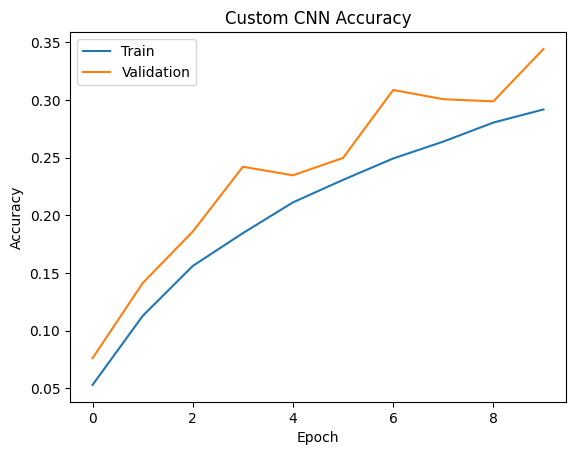

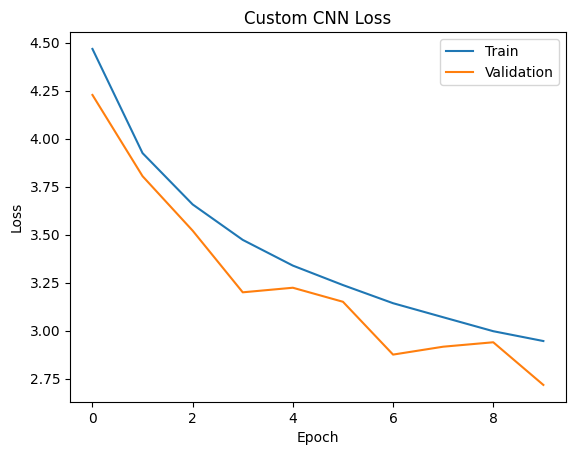

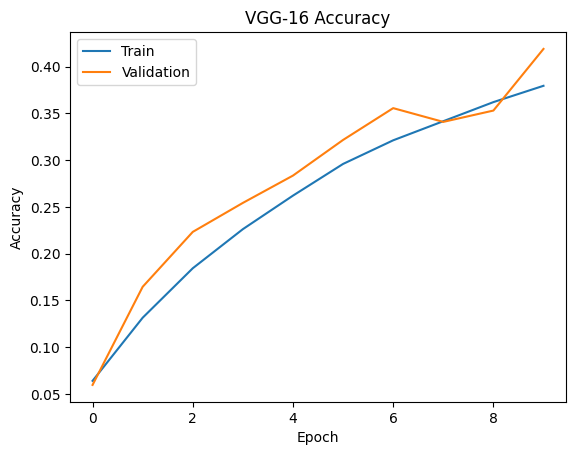

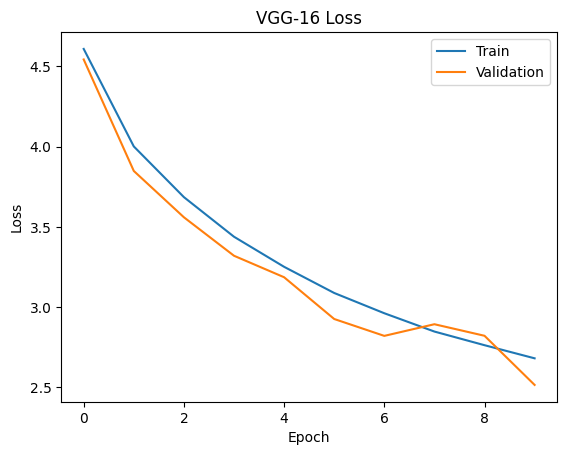

In [20]:
def plot_history(history, title):
    plt.figure()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(["Train","Validation"])
    plt.show()

    plt.figure()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(title + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(["Train","Validation"])
    plt.show()

plot_history(history_custom, "Custom CNN")
plot_history(history_vgg, "VGG-16")

## Model Summaries

In [21]:
print("Custom CNN Summary")
model_custom.summary()

print("VGG-16 Summary")
model_vgg.summary()

Custom CNN Summary


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,073,614 (7.91 MB)

 Trainable params: 690,820 (2.64 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 8, 8, 256)      │             

 Total params: 9,894,382 (37.74 MB)

 Trainable params: 3,297,188 (12.58 MB)

 Non-trainable params: 2,816 (11.00 KB)

 Optimizer params: 6,594,378 (25.16 MB)

## Architecture Diagrams

In [22]:
plot_model(model_custom, to_file="custom_cnn_architecture.png", show_shapes=True)
plot_model(model_vgg, to_file="vgg16_architecture.png", show_shapes=True)

print("Architecture diagrams saved.")


Architecture diagrams saved.
